(sec:monomer-qme-numerical)=
# QME: Numerical solution

We solve the master equation numerically using QuTiP package.  Here is the master equation again. 

$$
\frac{d}{dt} \rho = -\frac{i}{\hbar} \left[H_\text{rwa},\rho\right]+ \mathcal{D}(\rho)
$$

with 

$$
H_\text{rwa} = \frac{\hbar}{2}{\Delta} \sigma_{3} - \frac{\hbar}{2} \Omega \sigma_{1}
$$

and


$$
\mathcal{D}(\rho) = \gamma_{0} \left(\sigma_{-}\rho\sigma_{+} - \frac{1}{2} \sigma_{+}\sigma_{-}\rho - \frac{1}{2} \rho \sigma_{+}\sigma_{-} \right)
$$

The difference from the numerical calculation in {numref}`sec:openqm-qme-example` is only the presence of the driving term. Hence, we just modify the previous code.  Try different values for $\Delta$ and $\Omega$.

## Steady state

As discussed in {numref}`sec:openqm-qme-example`, the steady state solution to a quantum master equation is needed to evaluate physical quantities. When an analytical solution is not known, we need to find the steady state by solving the master equation numerically.  There is a build-in module in QuTiP `steadystate()` which computes the steady state for a given Liouvillian operator.  There is a untility function `liouvilian()` which creates Liouvillian superoperator from Hamiltonian and collapse operators.
The following code computes a steady state and compare the results with the analytical solution given in {numref}`sec:monomer-qme-theory`.  The agreement is perfect.

In [15]:
# ignore warnings (qutip issues various unwanted warnings)
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# Parameters
omega0 = 1.0
Delta = 0.0   # detuning
gamma0 = 0.1  # spontaneous emission rate
Omega = 0.2   # Rabi frequency

# Hamiltonian for a two-level system (in the rotating frame)
H = 0.5 * Delta * sigmaz() - 0.5 * Omega * sigmax()

# Jump operators
c_ops = [np.sqrt(gamma0) * sigmam()]

# Liouvillian
L = liouvillian(H,c_ops)

# get sterady state
rho = steadystate(L)

# exact solutions
rho_gg = 0.5 + (gamma0**2+4*Delta**2)/(2*(gamma0**2+2*Omega**2+4*Delta**2))
rho_ee = 0.5 - (gamma0**2+4*Delta**2)/(2*(gamma0**2+2*Omega**2+4*Delta**2))
rho_ge = - Omega*(2*Delta-1j*gamma0)/(gamma0**2+2*Omega**2+4*Delta**2)

print(f'          rho_gg    rho_ee       rho_ge')
print(f'theory:  {rho_gg:.5f}   {rho_ee:.5f}   {rho_ge:.5f}')
print(f' qutip:  {rho.full()[1,1].real:.5f}   {rho.full()[0,0].real:.5f}   {rho.full()[1,0]:.5f}')

          rho_gg    rho_ee       rho_ge
theory:  0.55556   0.44444   0.00000+0.22222j
 qutip:  0.55556   0.44444   0.00000-0.22222j


## Time evolution of density operator


The difference from the numerical calculation in {numref}`sec:openqm-qme-example` is only the presence of the driving term. Hence, we just modify the previous code.  Try different values for $\Delta$ and $\Omega$.

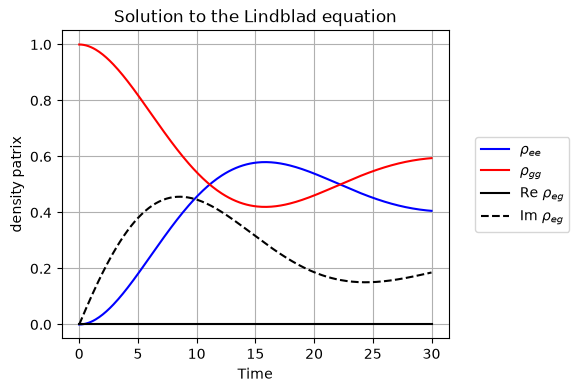

In [16]:
# Continued from the previous code block.
# Execute it before running this code block.

# Initial state: start in the ground state |g>
psi0 = basis(2,1)

# evaluation time
times = np.linspace(0, 30, 300)

# solve the master equation
result = mesolve(H, psi0, times, c_ops, e_ops=[])
states = [rho.full() for rho in result.states]

# get the density matrix
rho_00 = [np.real(rho[0, 0]) for rho in states]
rho_11 = [np.real(rho[1, 1]) for rho in states]
rho_01_r = [np.real(rho[0, 1]) for rho in states]
rho_01_i = [np.imag(rho[0, 1]) for rho in states]

# 4. Plotting the Time Evolution
plt.figure(figsize=(5, 4))
plt.plot(times,rho_00, label=r"$\rho_{ee}$",c='b')
plt.plot(times,rho_11, label=r"$\rho_{gg}$",c='r')
plt.plot(times,rho_01_r, label=r"Re $\rho_{eg}$",c='k')
plt.plot(times,rho_01_i, label=r"Im $\rho_{eg}$",c='k',linestyle='--')
plt.title("Solution to the Lindblad equation")
plt.xlabel("Time")
plt.ylabel("density patrix")
plt.legend(bbox_to_anchor=(1.05, 0.5),loc="center left")
plt.grid(True)
plt.show()

The trajectory of state is shown in the Bloch sphere.  The initial state $|g\rangle$  (shown as $|1\rangle$) is a pure state appearing on the surface of the sphere. As time goes,  the state becomes mixed and moving toward inside the sphere.

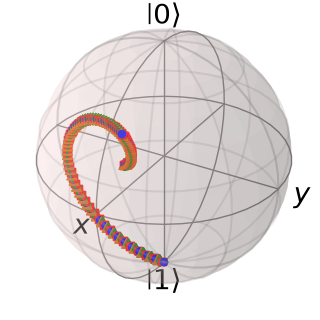

In [11]:
b = Bloch(figsize=(3,3))
b.add_states(result.states,kind='point')
b.show()

## The second order coherence

We can use the same code as given in {numref}`sec:openqm-qme-example`. The coherence vanishes at $\tau=0$ as expected for the emission from a single emitter.  Notice the Rabi oscillation around the dip caused by the driving.  The agreemwnt with the thoretical prediction {eq}`eq:monomer-g2-theory`mis quite good.

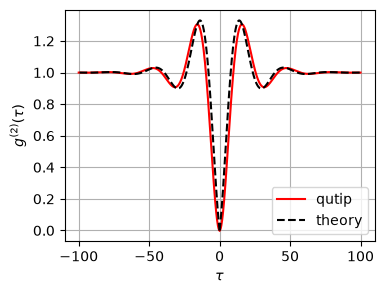

In [30]:
# Continued from the previous code block. 
# Execute it before running this code block.
times = np.linspace(0, 100, 500)
g2, G2 = coherence_function_g2(H, None, times, c_ops, sigmam())
g2_th = 1 - np.exp(-3*gamma0/4*times)*np.cos(Omega*times)
plt.figure(figsize=(4,3))
plt.plot(times, np.real(g2),c='r',label="qutip")
plt.plot(-times,np.real(g2), c='r')
plt.plot(times, np.real(g2_th),c='k',ls='--',label="theory")
plt.plot(-times,np.real(g2_th), c='k',ls='--')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.legend(loc=4)
plt.grid(True)
plt.show()